# **"Internship task by Decodelabs"**

- **Intership Duration : 25th-April-2026 - 25th-May-2026**

- **Project : 1**

     **Task : 1 - Data Collection & Data Understanding**

     **Task : 2 - Data Cleaning & Preprocessing**

     **Task : 3 - Exploratory Data Analysis (EDA)**


     **Task : 4 - Data Visulization**

     **Task : 5 - Predictive Model or Insight Project**

- **Data Source : From Kaggle**

- **DataSet Name :  Bank Customers Churn Prediction**

- **Domain : Data Science**

- **Submitted By : Palwasha Mushtaq**

# **DATA INTRODUCTION:**

**Bank Customer Churn Prediction is a data science problem where we analyze bank customers’ behavior to identify those who are likely to leave the bank (churn). By using historical data such as account balance, credit score, age, and activity status, machine learning models can predict churn in advance. This helps banks take proactive actions like improving customer service or offering personalized incentives to retain valuable customers.**


# **Import Libraries**

In [137]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

# **DATA LOAD**

In [138]:
df = pd.read_csv('Bank Customer Churn Prediction.csv')
print(df.head())

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  


# **DATA OVERVIEW**

In [139]:
print("DATA SHAPE")
print(df.shape)
print("======================================================================")
print("DATA NFORMATION")
df.info()
print("======================================================================")
print("DATA COLUMNS")
print(df.columns)
print("======================================================================")
print("DESCRIPTIVE STATISTICS SUMMARY")
print(df.describe())
print("======================================================================")
print("CHURN VALUES IN DATA")
print(df['churn'].value_counts())
print(df['churn'].value_counts(normalize=True) * 100)

DATA SHAPE
(10000, 12)
DATA NFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB
DATA COLUMNS
Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'acti

**Afer overviwed the data it is understand that, this data contains 10,000 rows and 12 columns, the RangeIndex: 891 entries, 0 to 9999.it has the following data types like: float64(2), int64(8), strings(2), and around 20% customers have churned, indicating a moderately imbalanced classification problem.**

# **Data Preprocessing**

- **Check missing Values**

In [140]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

- **Check Duplicates Values**

In [141]:
df.duplicated().sum()

np.int64(0)

**The dataset was checked for data quality issues. No missing values or duplicate records were found, which means the dataset is complete and consistent. Therefore, no data cleaning was required before proceeding to analysis and model building.**

- **Drop Unnecessary Column**

In [142]:
df.drop(columns=["customer_id"],inplace =True)
print(df)

      credit_score  country  gender  age  tenure    balance  products_number  \
0              619   France  Female   42       2       0.00                1   
1              608    Spain  Female   41       1   83807.86                1   
2              502   France  Female   42       8  159660.80                3   
3              699   France  Female   39       1       0.00                2   
4              850    Spain  Female   43       2  125510.82                1   
...            ...      ...     ...  ...     ...        ...              ...   
9995           771   France    Male   39       5       0.00                2   
9996           516   France    Male   35      10   57369.61                1   
9997           709   France  Female   36       7       0.00                1   
9998           772  Germany    Male   42       3   75075.31                2   
9999           792   France  Female   28       4  130142.79                1   

      credit_card  active_member  estim

**The customer_id column was dropped as it is irrelevant for analysis and does not contribute to the prediction.**

# **Exploratory Data Analysis(EDA)**

- **Statistical Analysis**

In [143]:
print("RATE OF CHURN IN THE DATA")
print(df["churn"].mean())

RATE OF CHURN IN THE DATA
0.2037


In [144]:
print("GROUP WISE CHURN RATE")
print("===================================================================")
print(df.groupby("gender")["churn"].mean())
print("===================================================================")
print("COUNTRIES WISE CHURN RATE")
print(df.groupby("country")["churn"].mean())
print("===================================================================")
print("AGE GROUP WISE CHURN RATE")
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
print(df.groupby("age_group")["churn"].mean())
print("===================================================================")
print("ACTIVE MEMBER WISE CHURN RATE")
print(df.groupby("active_member")["churn"].mean())
print("===================================================================")
print("BALANCE GROUP WISE CHURN RATE")
df['balance_group'] = pd.qcut(df['balance'], q=4, duplicates='drop')
print(df.groupby('balance_group')['churn'].mean())
print("===================================================================")
print("CREDIT SCORE GROUP WISE CHURN RATE")
df['credit_score_group'] = pd.cut(df["credit_score"], bins=5)
print(df.groupby('credit_score_group')['churn'].mean())
print("===================================================================")
print("TENURE GROUP WISE CHURN RATE")
df['tenure_group'] = pd.cut(df['tenure'], bins=5)
print(df.groupby('tenure_group')['churn'].mean())
print("===================================================================")    
print("ESTIMATED SALARY GROUP WISE CHURN RATE")
df['estimated_salary_group'] = pd.cut(df['estimated_salary'], bins=5)
print(df.groupby('estimated_salary_group')['churn'].mean())


GROUP WISE CHURN RATE
gender
Female    0.250715
Male      0.164559
Name: churn, dtype: float64
COUNTRIES WISE CHURN RATE
country
France     0.161548
Germany    0.324432
Spain      0.166734
Name: churn, dtype: float64
AGE GROUP WISE CHURN RATE
age_group
Young          0.075203
Middle-aged    0.195835
Senior         0.446471
Name: churn, dtype: float64
ACTIVE MEMBER WISE CHURN RATE
active_member
0    0.268509
1    0.142691
Name: churn, dtype: float64
BALANCE GROUP WISE CHURN RATE
balance_group
(-0.001, 97198.54]        0.1576
(97198.54, 127644.24]     0.2628
(127644.24, 250898.09]    0.2368
Name: churn, dtype: float64
CREDIT SCORE GROUP WISE CHURN RATE
credit_score_group
(349.5, 450.0]    0.322751
(450.0, 550.0]    0.214385
(550.0, 650.0]    0.207780
(650.0, 750.0]    0.192496
(750.0, 850.0]    0.195870
Name: churn, dtype: float64
TENURE GROUP WISE CHURN RATE
tenure_group
(-0.01, 2.0]    0.211538
(2.0, 4.0]      0.208208
(4.0, 6.0]      0.204649
(6.0, 8.0]      0.182172
(8.0, 10.0]     0

**The overall churn rate in the data is 20.37%. Group-wise analysis shows that churn is mainly driven by age, active_member status, gender, and country. Senior customers have the highest churn rate of 44.6% compared to only 7.5% for young customers. Inactive members churn at 26.8% while active members churn at only 14.2%. Female customers show higher churn at 25.1% vs 16.4% for males. Country-wise, Germany has the highest churn at 32.4% while France and Spain are lower at 16.1% and 16.7%. Customers with mid-range balances and lower credit scores also tend to churn more. However, tenure and estimated_salary show very little variation across groups, indicating they have minimal impact on churn.**

**Hence: Age, activity status, gender, and country are the strongest indicators of churn, which matches the correlation heatmap results.**

- **Data Visualization**

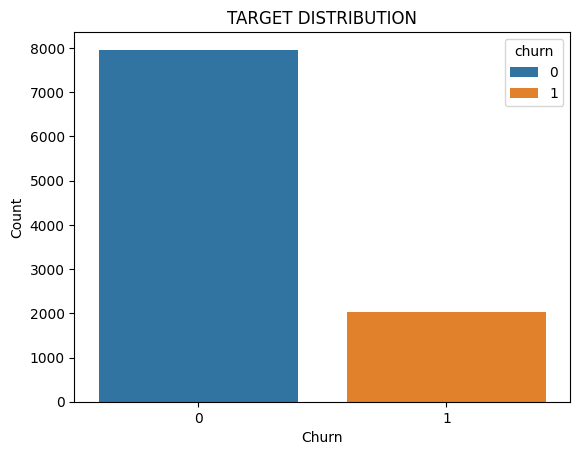

In [145]:
sns.countplot(x="churn",hue="churn",data=df)
plt.title("TARGET DISTRIBUTION")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

**The target variable distribution shows that around 80% of customers are non-churners, while approximately 20% are churners. This imbalance suggests that the dataset is skewed towards the majority class, which may affect model performance if not handled properly.**

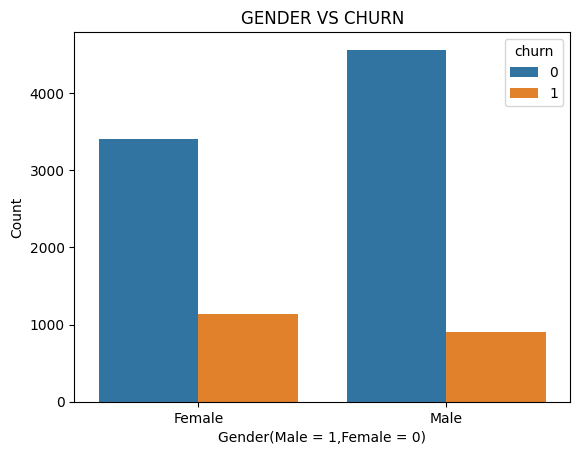

In [146]:
sns.countplot(x="gender",hue="churn",data=df)
plt.title("GENDER VS CHURN")
plt.xlabel("Gender(Male = 1,Female = 0)")
plt.ylabel("Count")
plt.show()

**The gender vs churn countplot shows that although male customers are higher in number, female customers have a higher churn count compared to males. This indicates that female customers are more likely to leave the bank.**

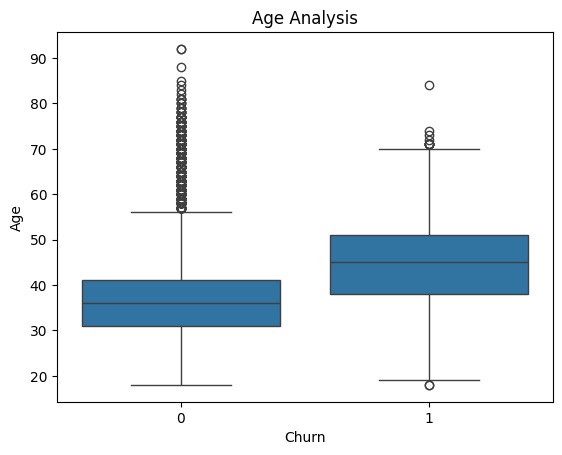

In [147]:
sns.boxplot(x="churn", y="age",data = df)
plt.title("Age Analysis")
plt.xlabel("Churn")
plt.ylabel("Age")
plt.show()

**The boxplot shows that customers who churn tend to be older, with a higher median age compared to non-churn customers. This suggests that age is an important factor influencing customer churn, as older customers are more likely to leave the bank.**

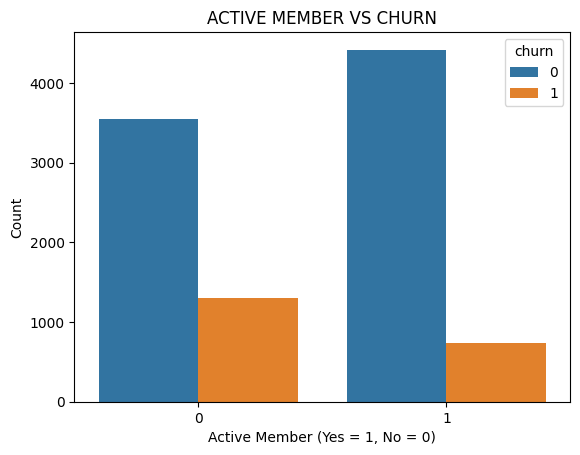

In [148]:
sns.countplot(x='active_member', hue='churn', data=df)
plt.title("ACTIVE MEMBER VS CHURN")
plt.xlabel("Active Member (Yes = 1, No = 0)")
plt.ylabel("Count")
plt.show()

**The active member vs churn countplot shows that although active members are higher in number, inactive members have a higher churn count compared to active ones. This indicates that inactive customers are more likely to leave the bank.**

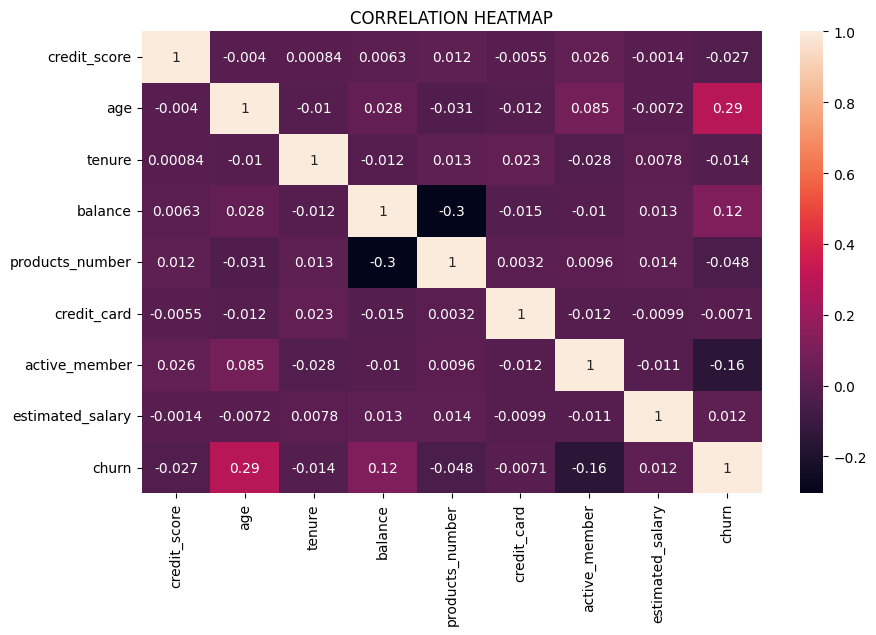

In [149]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.title("CORRELATION HEATMAP")
plt.show()

**The correlation heatmap shows that churn is mainly influenced by age, active_member, country_Germany, and balance. The positive correlation of 0.29 with age indicates that older customers are more likely to leave the bank, while the negative correlation of -0.16 with active_member indicates that active customers are less likely to churn. Customers from Germany and those with higher balances also show a higher tendency to churn. Other features like credit_score, tenure, and estimated_salary have very weak correlation with churn, indicating they have little direct linear impact on customers leaving the bank.**

**GroupBy Analysis & Feature Removal**

In [150]:
df = df.drop(['balance_group', 'age_group', 'credit_score_group','tenure_group','estimated_salary_group'], axis=1)

**During exploratory data analysis, group-by analysis was performed on selected features to understand their relationship with the target variable. However, the derived feature was later dropped before model training to avoid redundancy and ensure compatibility with SMOTE, as it was causing issues during resampling.**

- **Encoding**

In [151]:
le = LabelEncoder()
df["gender"]= le.fit_transform(df["gender"])
print('\n LABEL ENCODING(GENDER)')
print(df.head(10))


 LABEL ENCODING(GENDER)
   credit_score  country  gender  age  tenure    balance  products_number  \
0           619   France       0   42       2       0.00                1   
1           608    Spain       0   41       1   83807.86                1   
2           502   France       0   42       8  159660.80                3   
3           699   France       0   39       1       0.00                2   
4           850    Spain       0   43       2  125510.82                1   
5           645    Spain       1   44       8  113755.78                2   
6           822   France       1   50       7       0.00                2   
7           376  Germany       0   29       4  115046.74                4   
8           501   France       1   44       4  142051.07                2   
9           684   France       1   27       2  134603.88                1   

   credit_card  active_member  estimated_salary  churn  
0            1              1         101348.88      1  
1            

In [152]:
df= pd.get_dummies(df,columns=["country"],dtype=int)
print('\n ONE HOT ENCODING(COUNTRY)')
print(df.head(10))


 ONE HOT ENCODING(COUNTRY)
   credit_score  gender  age  tenure    balance  products_number  credit_card  \
0           619       0   42       2       0.00                1            1   
1           608       0   41       1   83807.86                1            0   
2           502       0   42       8  159660.80                3            1   
3           699       0   39       1       0.00                2            0   
4           850       0   43       2  125510.82                1            1   
5           645       1   44       8  113755.78                2            1   
6           822       1   50       7       0.00                2            1   
7           376       0   29       4  115046.74                4            1   
8           501       1   44       4  142051.07                2            0   
9           684       1   27       2  134603.88                1            1   

   active_member  estimated_salary  churn  country_France  country_Germany  \
0 

**Label Encoding is applied to the 'Gender' column to convert categorical values into numerical form. For example, 'male' is converted to 1 and 'female' to 0. This allows the machine learning model to process gender as a numerical feature.**

**One-Hot Encoding is used to transform the 'Country' column into multiple binary columns. Each category (such as france, Germany, Spain) is represented as a separate column with values 0 or 1. This prevents the model from assuming any ordinal relationship between categories.**

- **Split Data For Training and Testing**

In [153]:
X = df.drop('churn',axis = 1)
y =df['churn']
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size = 0.2, random_state= 42, stratify=y)
print("Training Data")
print(X_train)
print("Testing Data")
print(X_test)

Training Data
      credit_score  gender  age  tenure    balance  products_number  \
2151           753       1   57       7       0.00                1   
8392           739       1   32       3  102128.27                1   
5006           755       0   37       0  113865.23                2   
4117           561       1   37       5       0.00                2   
7182           692       1   49       6  110540.43                2   
...            ...     ...  ...     ...        ...              ...   
4555           688       0   35       6       0.00                1   
4644           712       1   74       5       0.00                2   
8942           667       0   37       9   71786.90                2   
2935           687       1   35       8  100988.39                2   
6206           802       1   51       7       0.00                1   

      credit_card  active_member  estimated_salary  country_France  \
2151            1              0         159475.08             

**Selected "churn" as important features for model training.and Splitting/ Divided data into training and testing sets"**

- **Apply Standard Scaler**

In [154]:
standardscaler = StandardScaler()
col = ['credit_score','age','tenure','balance','estimated_salary']
X_train[col] = standardscaler.fit_transform(X_train[col])
print('STANDARD_SCALER_TRAINING_DATA_OUTPUT:\n', X_train[col].head(5))

STANDARD_SCALER_TRAINING_DATA_OUTPUT:
       credit_score       age    tenure   balance  estimated_salary
2151      1.058568  1.715086  0.684723 -1.226059          1.042084
8392      0.913626 -0.659935 -0.696202  0.413288         -0.623556
5006      1.079274 -0.184931 -1.731895  0.601687          0.308128
4117     -0.929207 -0.184931 -0.005739 -1.226059         -0.290199
7182      0.427035  0.955079  0.339492  0.548318          0.135042


**StandardScaler is applied to numerical features like credit_score','age','tenure','balance',and 'estimated_salary to normalize their values. This ensures that all features are on a similar scale, which helps the model perform more effectively and improves convergence.**

- **Apply SMOTE (to balance the data)**

In [155]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [156]:
print("Before SMOTE:")
print(y_train.value_counts(normalize=True) * 100)

print("\nAfter SMOTE:")
print(y_res.value_counts(normalize=True) * 100)

Before SMOTE:
churn
0    79.625
1    20.375
Name: proportion, dtype: float64

After SMOTE:
churn
1    50.0
0    50.0
Name: proportion, dtype: float64


**The dataset initially had an imbalanced distribution, with a churn rate of 20.37%, meaning most customers did not leave the bank. Before applying SMOTE, 79.45% of customers were non-churners while only 20.55% were churners. To address this imbalance, SMOTE was applied, resulting in a balanced dataset with equal representation of both classes (50% each), which improves the model’s ability to correctly predict churn.**

# **Model Building**

- **XGBoost_Model**

In [157]:
XGB_model = XGBClassifier(random_state=42)
XGB_model.fit(X_res, y_res)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

**XGBoost model was trained on SMOTE-balanced data to improve prediction of the minority (churn) class.**

In [158]:
y_pred_XGB = XGB_model.predict(X_test)
print(y_pred_XGB)

[0 0 0 ... 1 0 0]


**The XGBoost model predicts churn (1) or non-churn (0) for each customer in the test dataset.**

- **GradientBoostingClassifier_Model**

In [159]:
GBC_model = GradientBoostingClassifier(random_state=42)
GBC_model.fit(X_res, y_res)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

**Gradient Boosting model was trained on SMOTE-balanced data to improve learning for the minority (churn) class.**

In [160]:
y_pred_GBC = GBC_model.predict(X_test)
print(y_pred_GBC)

[0 0 0 ... 1 0 1]


**The model predicts class labels (0 = non-churn, 1 = churn) for each customer in the test dataset.**

# **Data Evaluation**

- **Classification Report**

In [161]:
print("XGB_REPORT")
print(classification_report(y_test, y_pred_XGB))
print("GBC_REPORT")
print(classification_report(y_test, y_pred_GBC))

XGB_REPORT
              precision    recall  f1-score   support

           0       0.85      0.77      0.81      1593
           1       0.35      0.48      0.40       407

    accuracy                           0.71      2000
   macro avg       0.60      0.62      0.60      2000
weighted avg       0.75      0.71      0.73      2000

GBC_REPORT
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1593
           1       0.40      0.32      0.35       407

    accuracy                           0.76      2000
   macro avg       0.62      0.60      0.60      2000
weighted avg       0.75      0.76      0.75      2000



**Both models showed comparable performance; however, XGBoost performed better in identifying churn customers by achieving higher recall and F1-score for the churn class, while Gradient Boosting Classifier achieved slightly higher overall accuracy but performed weaker on the minority class. Therefore, XGBoost is more effective for churn prediction as correctly identifying churn customers is the main business objective.**

- **Confusion Matrixs**

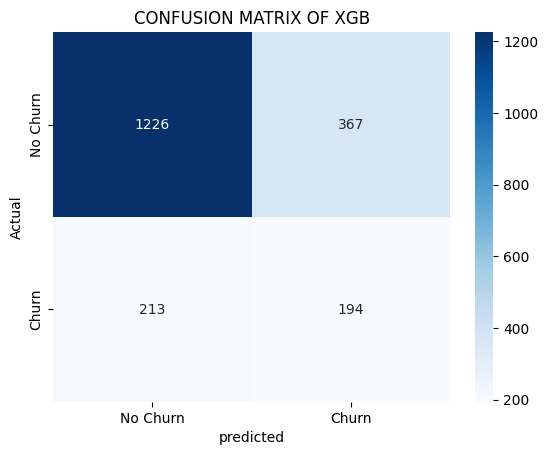

In [162]:
cm = confusion_matrix(y_test,y_pred_XGB)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('CONFUSION MATRIX OF XGB')
plt.show()

**The XGBoost model correctly identified most non-churn customers (1226 true negatives) and successfully predicted 194 churn customers (true positives). However, 213 churn customers were misclassified as non-churn, and 367 non-churn customers were incorrectly predicted as churn.**

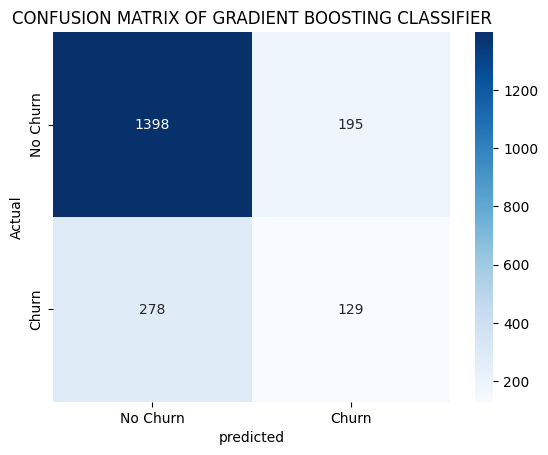

In [163]:
cm = confusion_matrix(y_test,y_pred_GBC)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('CONFUSION MATRIX OF GRADIENT BOOSTING CLASSIFIER')
plt.show()

**The Gradient Boosting Classifier correctly identified a large number of non-churn customers (1398 true negatives) and correctly predicted 129 churn customers (true positives). However, 278 churn customers were misclassified as non-churn, and 195 non-churn customers were incorrectly predicted as churn.**

**“Hence : XGBoost performed better than Gradient Boosting in identifying churn customers, as it correctly detected more churn cases and produced fewer false negatives. Since correctly identifying churn customers is the main business objective, XGBoost is the more suitable model for this problem.**

# **Overall Business Summary**

1. **BUSINESS PROBLEM:**

    The bank is experiencing a customer churn rate of 20.37%, meaning a significant number of customers are leaving.

     **Key business challenges:**
     - Loss of valuable customers (especially high balance & senior customers).
     - High churn in Germany region.
     - Inactive customers are more likely to leave.
     - Imbalanced dataset affecting prediction performance.


2. **SOLUTION:**

     **A machine learning-based churn prediction system was built to identify customers at risk of leaving.**

     **Steps performed:**

     - Data cleaning (no missing values, no duplicates)

     - Statistic Analysis

     - Exploratory Data Analysis (EDA)

     - Feature encoding (Gender, Country)

     - Split the data for training and testing

     - Feature scaling (StandardScaler)

     - Handling class imbalance using SMOTE

     **Model training:**

     - XGBoost and Gradient Boosting

     **Model evaluation:**

     - Classification Report

     - Confusion Matrix



3. **KEY INSIGHTS (BUSINESS ANALYSIS):**

      - Senior / older customers have higher churn probability.
      - Inactive members are more likely to churn.
      - Germany customers show highest churn rate.
      - Customers with higher balance also show churn tendency.**
      - Active members are more loyal.
      - Country France shows lower churn compared to Germany.


4. **RECOMMENDATIONS:**

     **1. Customer Retention Strategy**

     - Focus on high-risk groups:

     - Senior customers

     - Inactive members

     - Germany-based customers

     **2. Engagement Improvement**

     - Increase customer engagement campaigns

     - Reactivate inactive users through offers

     - Improve digital banking experience

     **3. Targeted Marketing**

     - Personalized offers for high-balance customers

     - Loyalty rewards for long-term customers

     **4. Model Usage in Business**

     - Use Gradient Boosting model for production

     - Monitor churn probability regularly

     - Early warning system for at-risk customers

# **FINAL CONCLUSION :**

**Machine learning models were developed to predict customer churn using a banking dataset containing 10,000 customer records. The dataset was preprocessed through data cleaning, encoding, feature scaling, and class balancing using SMOTE to improve model performance.**

**Two classification models, XGBoost and Gradient Boosting Classifier, were trained and evaluated. Both models showed comparable overall performance; however, XGBoost achieved an accuracy of 71%, while Gradient Boosting Classifier achieved a slightly higher accuracy of 76%.**

**Despite having slightly lower accuracy, XGBoost performed better in identifying churn customers. The confusion matrix results showed that XGBoost correctly identified 194 churn customers (True Positives) with 213 missed churn cases (False Negatives), whereas Gradient Boosting Classifier correctly identified 129 churn customers with 278 missed churn cases. This indicates that XGBoost is more effective in reducing false negatives, which is critical for churn prediction.**

**Hence, XGBoost was selected as the better-performing model for this project.**
